# Analysis and Visualization of Composite Diagnostics

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-06-21  

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
Created during Revision 1, this notebook generates Figure 6 using composite-analysis-derived diagnostics.


In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from numpy import dtype
from scipy import stats
from datetime import date
import collections
import cartopy.crs as ccrs
import os
from scipy.stats import circmean
import pickle
from scipy.ndimage import uniform_filter
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib import colors
from tqdm import tqdm
import copy

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
track_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/tracks'
composites_derived_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/composites'
composites_raw_dir = '/data/keeling/a/mingshi3/c/xshield/composites'

In [4]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3']

In [5]:
tk = []
idx = []
for exp in experiments:
    tk.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [6]:
xplot = (np.arange(201)*25-2500) / 1000

In [7]:
tk[0].shape, idx[0].shape

((45582, 4), (3593, 2))

In [8]:
def calc_lifestage_one_exp(tk_exp, idx_exp):
    """
    Return lifestage array with same length as tk_exp.

    Genesis = 0
    Lysis   = 1

    tk_exp:  one experiment track array, shape (n_sample, ...)
    idx_exp: start/end indices for each track, shape (n_track, 2)
    """

    idx_exp = np.asarray(idx_exp, dtype=int)

    lifestage = np.full(len(tk_exp), np.nan, dtype=np.float32)

    for im, ia in idx_exp:
        n = ia - im

        if n <= 0:
            continue
        elif n == 1:
            lifestage[im:ia] = 0.0
        else:
            lifestage[im:ia] = np.linspace(0, 1, n, dtype=np.float32)

    return lifestage


lifestage = []

for i in range(len(experiments)):
    lifestage.append(
        calc_lifestage_one_exp(tk[i], idx[i])
    )

    print(
        experiments[i],
        lifestage[i].shape,
        np.nanmin(lifestage[i]),
        np.nanmax(lifestage[i])
    )

PIRE (45582,) 0.0 1.0
PIRE_CO2_1270ppmv (44392,) 0.0 1.0
PIRE_PLUS_4K (39800,) 0.0 1.0
PIRE_PLUS_4K_CO2_1270ppmv (39286,) 0.0 1.0


In [9]:
tk_sel = []
lf_sel = []
for i, d in enumerate(tk):
    d = copy.deepcopy(d)
    sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
    d = d[sel]
    lf = copy.deepcopy(lifestage[i])[sel]
    tk_sel.append(d)
    lf_sel.append(lf)

In [10]:
def dmatrix(r,res):
    x = np.arange(-r,r+1e-10,res)
    y = x.copy()
    xx,yy = np.meshgrid(x,y)
    dm = np.ones_like(xx)
    dm[(xx**2+yy**2)>r**2] = np.nan
    return dm

dm250 = dmatrix(250,25)
dm500 = dmatrix(500,25)

presfc_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_PRATEsfc.pkl'
if os.path.isfile(presfc_XXX_file):
    with open(presfc_XXX_file,'rb') as f:
        presfc_XXX = pickle.load(f)
else:
    presfc_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_PRATEsfc.npy')
        print('m')
        presfc_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2))) # use distance mask to calculate area average
        del data
    with open(presfc_XXX_file,'wb') as f:
        pickle.dump(presfc_XXX,f)

cwv_XXX_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_cwv_925-200.pkl'
if os.path.isfile(cwv_XXX_file):
    with open(cwv_XXX_file,'rb') as f:
        cwv_XXX = pickle.load(f)
else:
    cwv_XXX = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'{composites_raw_dir}/TK2Y-{expf}_cwv_925-200.npy')
        print('m')
        cwv_XXX.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2)))
        del data
    with open(cwv_XXX_file,'wb') as f:
        pickle.dump(cwv_XXX,f)

In [11]:
presfc_XXX[0].shape, cwv_XXX[0].shape, tk_sel[0].shape, lf_sel[0].shape

((29192,), (29192,), (29192, 4), (29192,))

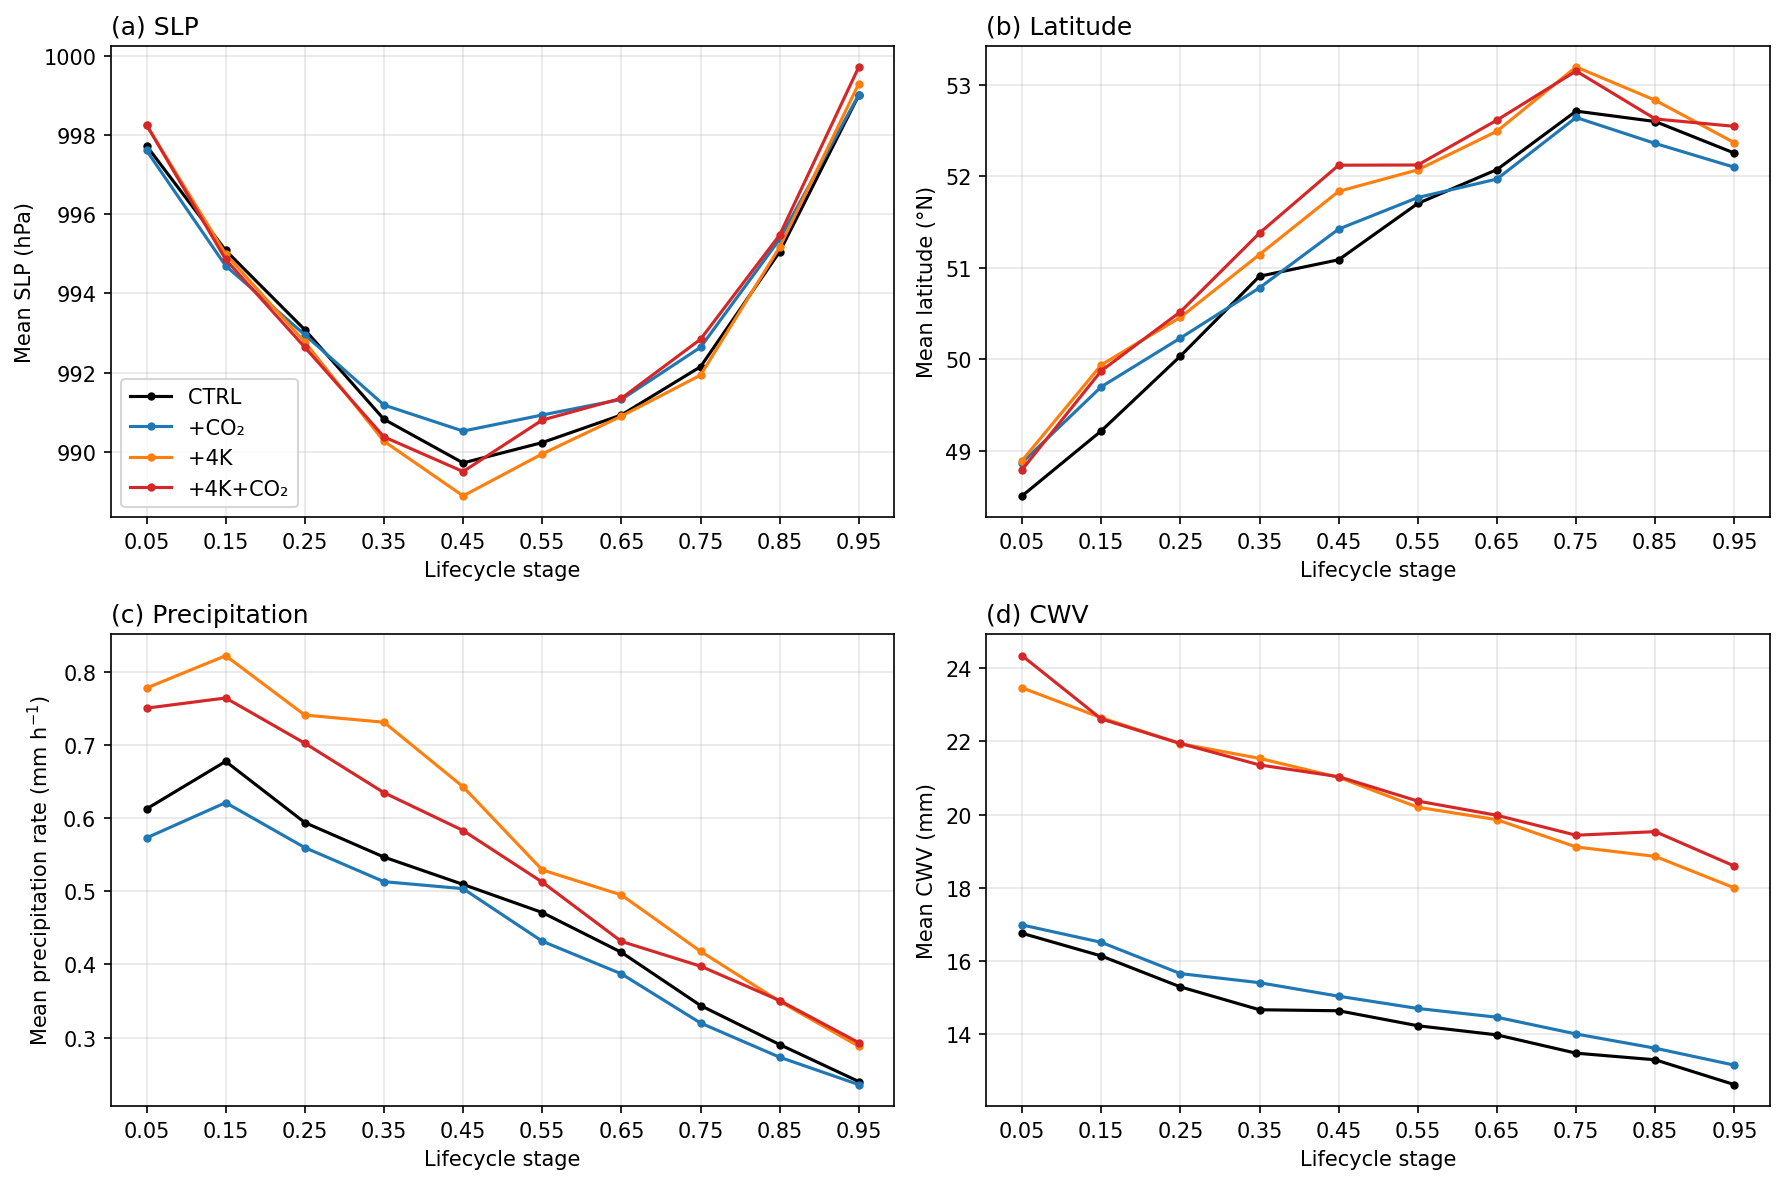

In [12]:
# lifecycle-stage-binned latitude / SLP / precipitation / CWV

nbin = 10
stage_edges = np.linspace(0, 1, nbin + 1)
stage_centers = 0.5 * (stage_edges[:-1] + stage_edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

plot_configs = [
    (
        [tk_sel[i][:, -1] for i in range(len(experiments_display))],
        'Mean SLP (hPa)',
        '(a) SLP'
    ),
    (
        [tk_sel[i][:, 1] for i in range(len(experiments_display))],
        'Mean latitude (°N)',
        '(b) Latitude'
    ),
    (
        [presfc_XXX[i] * 3600 for i in range(len(experiments_display))],
        'Mean precipitation rate (mm h$^{-1}$)',
        '(c) Precipitation'
    ),
    (
        [cwv_XXX[i] for i in range(len(experiments_display))],
        'Mean CWV (mm)',
        '(d) CWV'
    )
]

axes = axes.ravel()

for icol, (ydata_all, ylabel, title) in enumerate(plot_configs):

    ax = axes[icol]

    for i, exp in enumerate(experiments_display):

        x = lf_sel[i]
        y = ydata_all[i]

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        y_mean = []

        for ibin in range(nbin):

            if ibin == nbin - 1:
                m = (x >= stage_edges[ibin]) & (x <= stage_edges[ibin + 1])
            else:
                m = (x >= stage_edges[ibin]) & (x < stage_edges[ibin + 1])

            y_mean.append(np.nanmean(y[m]))

        ax.plot(
            stage_centers,
            y_mean,
            marker='.',
            label=exp.replace('\n', ''),
            color=colorlist[i + 1]
        )

    ax.set_xlabel('Lifecycle stage')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(stage_centers)
    ax.grid(alpha=0.3)

axes[0].legend()

plt.tight_layout()
plt.show()